# 04_generate_dataset_v2.ipynb

Генерация **основного train / val / test** датасета для ВКР.

Этот ноутбук делает только одно:
- читает `OpenBreastUS` speed maps;
- задаёт фиксированный split;
- генерирует для каждого фантома матрицу измерений `M[s, r]` через `j-Wave`;
- сохраняет пары `(x, c)` в `.npz`, где:
  - `x.shape == (2, S, R)` — `Re/Im`,
  - `c.shape == (H, W)` — downsample-нутая speed map;
- сохраняет:
  - `split_manifest.json`
  - `generation_config.json`

## Структура результата
```text
OUT_ROOT/
    train/
    val/
    test/
    split_manifest.json
    generation_config.json
```

## Предполагается
- JAX и j-Wave уже **установлены и работают** в текущем kernel.
- Этот ноутбук не занимается обучением — только генерацией датасета.

## 0. Проверка окружения

Если импорт `jax` или `jwave` здесь падает, сначала нужно починить окружение и только потом запускать генерацию.

In [1]:
import os
from pathlib import Path
import json
import time

import numpy as np
import scipy.io as sio
import h5py
import matplotlib.pyplot as plt
from scipy.ndimage import zoom

import jax
import jax.numpy as jnp
from jax import jit

from jwave import FourierSeries
from jwave.geometry import Domain, Medium
from jwave.acoustics.time_harmonic import helmholtz_solver

print("jax version:", jax.__version__)
print("devices:", jax.devices())

jax version: 0.4.38
devices: [CudaDevice(id=0)]


## 1. Пути к исходным `.mat` файлам

Подставь свои пути, если они отличаются.

In [2]:
from huggingface_hub import hf_hub_download

test_speed_path = hf_hub_download(
    repo_id="OpenBreastUS/breast",
    repo_type="dataset",
    filename="breast_test_speed.mat",
)

train_speed_path = hf_hub_download(
    repo_id="OpenBreastUS/breast",
    repo_type="dataset",
    filename="breast_train_speed.mat",
)

print("test_speed_path:", test_speed_path)
print("train_speed_path:", train_speed_path)

test_speed_path: /root/.cache/huggingface/hub/datasets--OpenBreastUS--breast/snapshots/98646e39b9083a5481c6c4070ac2ffbe4f19c393/breast_test_speed.mat
train_speed_path: /root/.cache/huggingface/hub/datasets--OpenBreastUS--breast/snapshots/98646e39b9083a5481c6c4070ac2ffbe4f19c393/breast_train_speed.mat


In [3]:
assert Path(test_speed_path).exists(), f"Not found: {test_speed_path}"
assert Path(train_speed_path).exists(), f"Not found: {train_speed_path}"

print("test_speed_path:", test_speed_path)
print("train_speed_path:", train_speed_path)

test_speed_path: /root/.cache/huggingface/hub/datasets--OpenBreastUS--breast/snapshots/98646e39b9083a5481c6c4070ac2ffbe4f19c393/breast_test_speed.mat
train_speed_path: /root/.cache/huggingface/hub/datasets--OpenBreastUS--breast/snapshots/98646e39b9083a5481c6c4070ac2ffbe4f19c393/breast_train_speed.mat


## 2. Чтение `breast_test` и ленивое чтение `breast_train`

`breast_test` можно загрузить целиком.  
`breast_train` читаем лениво через `h5py`, чтобы не ловить OOM.

In [4]:
def load_test_array(test_speed_path: str) -> np.ndarray:
    d = sio.loadmat(test_speed_path)
    return d["breast_test"].astype(np.float32)

def get_train_len(train_speed_path: str) -> int:
    with h5py.File(train_speed_path, "r") as f:
        ds = f["breast_train"]
        if ds.shape[0] == 480 and ds.shape[1] == 480:
            return ds.shape[2]
        if ds.shape[1] == 480 and ds.shape[2] == 480:
            return ds.shape[0]
        raise ValueError(f"Unexpected train shape: {ds.shape}")

def get_train_slice(train_speed_path: str, i: int) -> np.ndarray:
    with h5py.File(train_speed_path, "r") as f:
        ds = f["breast_train"]

        if ds.shape[0] == 480 and ds.shape[1] == 480:
            if not (0 <= i < ds.shape[2]):
                raise IndexError(f"i={i} out of range 0..{ds.shape[2]-1}")
            return np.array(ds[:, :, i], dtype=np.float32)

        if ds.shape[1] == 480 and ds.shape[2] == 480:
            if not (0 <= i < ds.shape[0]):
                raise IndexError(f"i={i} out of range 0..{ds.shape[0]-1}")
            return np.array(ds[i], dtype=np.float32)

        raise ValueError(f"Unexpected train shape: {ds.shape}")

c_test = load_test_array(test_speed_path)
train_len = get_train_len(train_speed_path)

print("c_test:", c_test.shape, c_test.dtype, float(c_test.min()), float(c_test.max()))
print("train_len:", train_len)

train0 = get_train_slice(train_speed_path, 0)
print("train0:", train0.shape, train0.dtype, float(train0.min()), float(train0.max()))

c_test: (800, 480, 480) float32 1403.1455078125 1597.6688232421875
train_len: 7200
train0: (480, 480) float32 1426.887939453125 1554.2374267578125


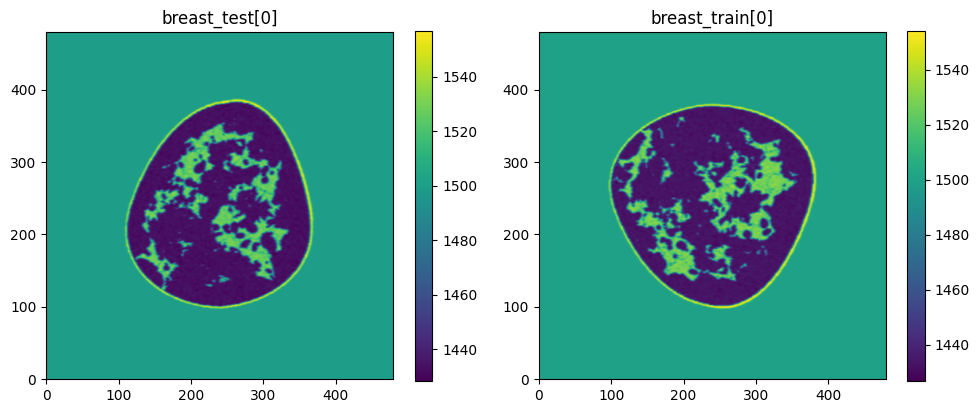

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

im0 = ax[0].imshow(c_test[0], origin="lower")
ax[0].set_title("breast_test[0]")
plt.colorbar(im0, ax=ax[0])

im1 = ax[1].imshow(train0, origin="lower")
ax[1].set_title("breast_train[0]")
plt.colorbar(im1, ax=ax[1])

plt.tight_layout()
plt.show()

## 3. Конфиг генерации

Это и есть основная рабочая конфигурация v2.  
Её потом стоит сохранить вместе с датасетом.

In [6]:
CFG = {
    "H": 192,
    "W": 192,
    "dx0": 0.3e-3,
    "freq_hz": 5e5,
    "density": 1000.0,
    "pml_size": 16,
    "num_sources": 16,
    "num_receivers": 256,
    "ring_alpha": 0.38,
    "source_sigma_px": 1.8,
}

CFG

{'H': 192,
 'W': 192,
 'dx0': 0.0003,
 'freq_hz': 500000.0,
 'density': 1000.0,
 'pml_size': 16,
 'num_sources': 16,
 'num_receivers': 256,
 'ring_alpha': 0.38,
 'source_sigma_px': 1.8}

## 4. Функции геометрии и симуляции

In [7]:
def downsample_speed_map(c_full: np.ndarray, out_hw=(192, 192)) -> np.ndarray:
    zh = out_hw[0] / c_full.shape[0]
    zw = out_hw[1] / c_full.shape[1]
    return zoom(c_full, (zh, zw), order=1).astype(np.float32)

def effective_dx(dx0: float, orig_hw=(480, 480), new_hw=(192, 192)):
    return (
        dx0 * orig_hw[0] / new_hw[0],
        dx0 * orig_hw[1] / new_hw[1],
    )

def ring_points(H: int, W: int, R: int, alpha: float):
    cy, cx = (H - 1) / 2.0, (W - 1) / 2.0
    rad = alpha * min(H - 1, W - 1)
    theta = np.linspace(0, 2 * np.pi, R, endpoint=False)

    ys = np.round(cy + rad * np.sin(theta)).astype(int)
    xs = np.round(cx + rad * np.cos(theta)).astype(int)

    ys = np.clip(ys, 0, H - 1)
    xs = np.clip(xs, 0, W - 1)
    return ys, xs, cy, cx, rad

def gaussian_source(H: int, W: int, y0: int, x0: int, sigma: float = 1.8):
    yy, xx = np.mgrid[0:H, 0:W]
    g = np.exp(-((yy - y0) ** 2 + (xx - x0) ** 2) / (2 * sigma**2))
    g = g / g.sum()
    return g.astype(np.float32)

def build_domain_and_medium(c_map: np.ndarray, cfg: dict):
    H, W = c_map.shape
    dx = effective_dx(cfg["dx0"], (480, 480), (H, W))
    domain = Domain((H, W), dx)
    sound_speed = FourierSeries(jnp.expand_dims(jnp.array(c_map), -1), domain)
    medium = Medium(
        domain=domain,
        sound_speed=sound_speed,
        density=cfg["density"],
        pml_size=cfg["pml_size"],
    )
    return domain, medium, dx

@jit
def solve_helmholtz_jit(medium, omega, src):
    return helmholtz_solver(medium, omega, src)

def simulate_field_for_source(c_map: np.ndarray, y0: int, x0: int, cfg: dict):
    H, W = c_map.shape
    domain, medium, dx = build_domain_and_medium(c_map, cfg)

    src_np = gaussian_source(H, W, y0, x0, sigma=cfg["source_sigma_px"])
    src_field = jnp.array(src_np, dtype=jnp.complex64)
    src = FourierSeries(jnp.expand_dims(src_field, -1), domain)

    omega = 2 * np.pi * cfg["freq_hz"]
    field = solve_helmholtz_jit(medium, omega, src * omega)
    u = np.array(field.params[..., 0])

    return u, dx

def simulate_measurement_matrix(c_map: np.ndarray, cfg: dict, verbose: bool = False):
    H, W = c_map.shape
    ys, xs, cy, cx, rad = ring_points(H, W, cfg["num_receivers"], cfg["ring_alpha"])
    src_idx = np.linspace(0, cfg["num_receivers"] - 1, cfg["num_sources"], dtype=int)

    M = np.zeros((cfg["num_sources"], cfg["num_receivers"]), dtype=np.complex64)
    U_preview = []

    for i, ridx in enumerate(src_idx):
        y0, x0 = int(ys[ridx]), int(xs[ridx])
        u, dx = simulate_field_for_source(c_map, y0, x0, cfg)
        M[i] = u[ys, xs]
        if i < 2:
            U_preview.append(u)
        if verbose:
            print(f"source {i+1}/{cfg['num_sources']} -> ring index {ridx}, coord=({y0}, {x0})")

    meta = {
        "receiver_y": ys,
        "receiver_x": xs,
        "source_ring_idx": src_idx,
        "cy": cy,
        "cx": cx,
        "rad": rad,
        "dx": np.array(dx, dtype=np.float32),
    }
    return M, U_preview, meta

def save_pair_npz(path, M_i, c_map, meta_i, cfg):
    x_i = np.stack([M_i.real, M_i.imag], axis=0).astype(np.float32)
    np.savez_compressed(
        path,
        x=x_i,
        c=c_map.astype(np.float32),
        receiver_y=meta_i["receiver_y"],
        receiver_x=meta_i["receiver_x"],
        source_ring_idx=meta_i["source_ring_idx"],
        dx=meta_i["dx"],
        freq_hz=np.array([cfg["freq_hz"]], dtype=np.float32),
    )

## 5. Быстрая проверка геометрии

Кольцо не должно попадать в PML.

ys min/max: 23 168
xs min/max: 23 168
inside non-PML: True


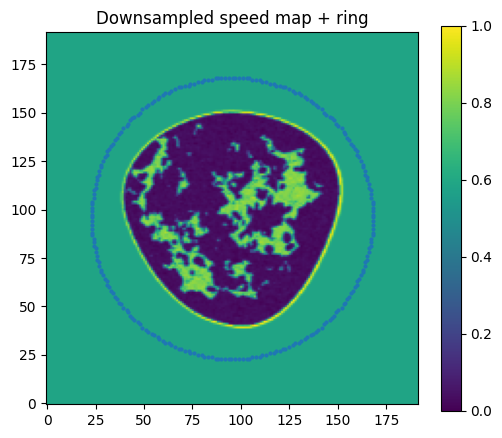

In [8]:
ys, xs, cy, cx, rad = ring_points(CFG["H"], CFG["W"], CFG["num_receivers"], CFG["ring_alpha"])

inside_non_pml = (
    (ys >= CFG["pml_size"]).all()
    and (ys < CFG["H"] - CFG["pml_size"]).all()
    and (xs >= CFG["pml_size"]).all()
    and (xs < CFG["W"] - CFG["pml_size"]).all()
)

print("ys min/max:", ys.min(), ys.max())
print("xs min/max:", xs.min(), xs.max())
print("inside non-PML:", inside_non_pml)

c0 = downsample_speed_map(train0, (CFG["H"], CFG["W"]))
plt.figure(figsize=(6, 5))
plt.imshow(c0, origin="lower")
plt.scatter(xs, ys, s=4)
plt.title("Downsampled speed map + ring")
plt.colorbar()
plt.show()

## 6. Split основного датасета

Это стартовый v2 split.  
Его легко поменять, но важно зафиксировать в `split_manifest.json`.

In [9]:
import json, random
from pathlib import Path

SEED = 42
TRAIN_TOTAL = 7200
TEST_TOTAL = 800

TRAIN_SIZE = 1440
VAL_SIZE = 200
TEST_SIZE = 200

rng = random.Random(SEED)

train_pool = list(range(TRAIN_TOTAL))
rng.shuffle(train_pool)

train_ids = sorted(train_pool[:TRAIN_SIZE])
val_ids = sorted(train_pool[TRAIN_SIZE:TRAIN_SIZE + VAL_SIZE])

test_pool = list(range(TEST_TOTAL))
rng.shuffle(test_pool)
test_ids = sorted(test_pool[:TEST_SIZE])

manifest = {
    "name": "usct_split_1440_200_200_seed42",
    "seed": SEED,
    "source_dataset": "OpenBreastUS",
    "source_shapes": {
        "breast_train_count": TRAIN_TOTAL,
        "breast_test_count": TEST_TOTAL,
    },
    "splits": {
        "train_source": "breast_train",
        "val_source": "breast_train",
        "test_source": "breast_test",
        "train_size": len(train_ids),
        "val_size": len(val_ids),
        "test_size": len(test_ids),
    },
    "train_ids_from_breast_train": train_ids,
    "val_ids_from_breast_train": val_ids,
    "test_ids_from_breast_test": test_ids,
}

out_dir = Path("/workspace/usct_dataset_v2")
json_path = out_dir / "split_manifest_8000_200_200_seed42.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(manifest, f, ensure_ascii=False, indent=2)


print(f"saved: {json_path}")
print("train head:", train_ids[:10])
print("val head:", val_ids[:10])
print("test head:", test_ids[:10])

saved: /workspace/usct_dataset_v2/split_manifest_8000_200_200_seed42.json
train head: [1, 6, 20, 25, 27, 35, 37, 40, 41, 44]
val head: [14, 31, 117, 131, 171, 184, 241, 266, 316, 476]
test head: [2, 3, 13, 15, 22, 24, 26, 39, 45, 48]


In [10]:
import json
import random

SEED = 42
TRAIN_TOTAL = 7200
TEST_TOTAL = 800

VAL_SIZE = 1000

rng = random.Random(SEED)

train_pool = list(range(TRAIN_TOTAL))
rng.shuffle(train_pool)

val_ids = sorted(train_pool[:VAL_SIZE])
train_ids = sorted(train_pool[VAL_SIZE:])

test_ids = list(range(TEST_TOTAL))  # весь официальный test

manifest = {
    "name": "usct_split_full_6200_1000_800_seed42",
    "seed": SEED,
    "train_ids_from_breast_train": train_ids,
    "val_ids_from_breast_train": val_ids,
    "test_ids_from_breast_test": test_ids,
}
out_dir = Path("/workspace/usct_dataset_v2")
json_path = out_dir / "usct_split_full_6200_1000_800_seed42.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(manifest, f, ensure_ascii=False, indent=2)
    
print(len(train_ids), len(val_ids), len(test_ids))

6200 1000 800


In [11]:
import json
from pathlib import Path

OUT_ROOT = Path("/workspace/usct_dataset_v2")
(OUT_ROOT / "train").mkdir(parents=True, exist_ok=True)
(OUT_ROOT / "val").mkdir(parents=True, exist_ok=True)
(OUT_ROOT / "test").mkdir(parents=True, exist_ok=True)

current = "usct_split_full_6200_1000_800_seed42"

with open("/workspace/usct_dataset_v2/usct_split_full_6200_1000_800_seed42.json", "r", encoding="utf-8") as f:
    split_manifest = json.load(f)

TRAIN_IDS = split_manifest["train_ids_from_breast_train"]
VAL_IDS = split_manifest["val_ids_from_breast_train"]
TEST_IDS = split_manifest["test_ids_from_breast_test"]

print(len(TRAIN_IDS), len(VAL_IDS), len(TEST_IDS))
generation_config = {
    "dataset_name": "usct_dataset_v2",
    "source_speed_maps": "OpenBreastUS",
    "train_source": "breast_train",
    "val_source": "breast_train",
    "test_source": "breast_test",
    "H": CFG["H"],
    "W": CFG["W"],
    "dx0": CFG["dx0"],
    "freq_hz": CFG["freq_hz"],
    "density": CFG["density"],
    "pml_size": CFG["pml_size"],
    "num_sources": CFG["num_sources"],
    "num_receivers": CFG["num_receivers"],
    "ring_alpha": CFG["ring_alpha"],
    "source_sigma_px": CFG["source_sigma_px"],
    "note": "raw M is stored; residual M-M_hom is computed during training",
}

with open(OUT_ROOT / "generation_config.json", "w", encoding="utf-8") as f:
    json.dump(generation_config, f, ensure_ascii=False, indent=2)

print("OUT_ROOT:", OUT_ROOT)
print("saved split_manifest.json")
print("saved generation_config.json")

6200 1000 800
OUT_ROOT: /workspace/usct_dataset_v2
saved split_manifest.json
saved generation_config.json


## 7. Smoke-test на 20 train примерах

Сначала оцениваем:
- корректность генерации;
- скорость на 1 пример;
- ориентировочное время полной генерации.

In [12]:
SMOKE_IDS = TRAIN_IDS[:20]
smoke_dir = OUT_ROOT / "train_smoke"
smoke_dir.mkdir(parents=True, exist_ok=True)

t0 = time.time()
for k, i in enumerate(SMOKE_IDS):
    c_full = get_train_slice(train_speed_path, i)
    c_map = downsample_speed_map(c_full, (CFG["H"], CFG["W"]))
    M_i, _, meta_i = simulate_measurement_matrix(c_map, CFG, verbose=False)

    out_path = smoke_dir / f"sample_{k:05d}.npz"
    save_pair_npz(out_path, M_i, c_map, meta_i, CFG)

    print(f"[{k+1}/{len(SMOKE_IDS)}] saved {out_path}")

t1 = time.time()
sec_per_example = (t1 - t0) / len(SMOKE_IDS)

print("sec/example:", sec_per_example)
print("estimated time for train+val+test (700 examples):", sec_per_example * 700 / 3600, "hours")

[1/20] saved /workspace/usct_dataset_v2/train_smoke/sample_00000.npz
[2/20] saved /workspace/usct_dataset_v2/train_smoke/sample_00001.npz
[3/20] saved /workspace/usct_dataset_v2/train_smoke/sample_00002.npz
[4/20] saved /workspace/usct_dataset_v2/train_smoke/sample_00003.npz
[5/20] saved /workspace/usct_dataset_v2/train_smoke/sample_00004.npz
[6/20] saved /workspace/usct_dataset_v2/train_smoke/sample_00005.npz
[7/20] saved /workspace/usct_dataset_v2/train_smoke/sample_00006.npz
[8/20] saved /workspace/usct_dataset_v2/train_smoke/sample_00007.npz
[9/20] saved /workspace/usct_dataset_v2/train_smoke/sample_00008.npz
[10/20] saved /workspace/usct_dataset_v2/train_smoke/sample_00009.npz
[11/20] saved /workspace/usct_dataset_v2/train_smoke/sample_00010.npz
[12/20] saved /workspace/usct_dataset_v2/train_smoke/sample_00011.npz
[13/20] saved /workspace/usct_dataset_v2/train_smoke/sample_00012.npz
[14/20] saved /workspace/usct_dataset_v2/train_smoke/sample_00013.npz
[15/20] saved /workspace/usct

smoke count: 20
['x', 'c', 'receiver_y', 'receiver_x', 'source_ring_idx', 'dx', 'freq_hz']
x: (2, 16, 256) float32
c: (192, 192) float32


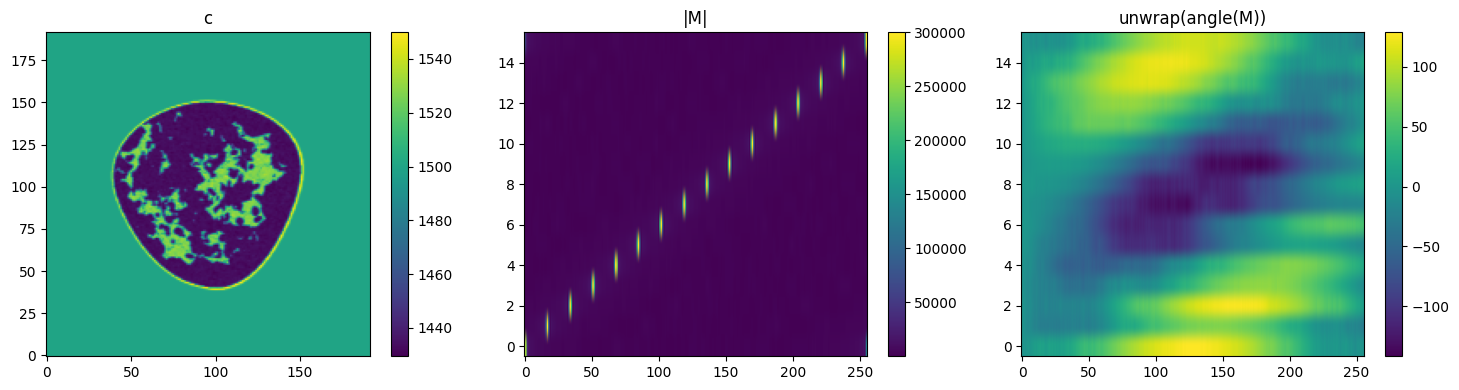

In [13]:
smoke_files = sorted(smoke_dir.glob("*.npz"))
print("smoke count:", len(smoke_files))

d0 = np.load(smoke_files[0])
print(d0.files)
print("x:", d0["x"].shape, d0["x"].dtype)
print("c:", d0["c"].shape, d0["c"].dtype)

M0 = d0["x"][0] + 1j * d0["x"][1]

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
im0 = ax[0].imshow(d0["c"], origin="lower")
ax[0].set_title("c")
plt.colorbar(im0, ax=ax[0])

im1 = ax[1].imshow(np.abs(M0), aspect="auto", origin="lower")
ax[1].set_title("|M|")
plt.colorbar(im1, ax=ax[1])

im2 = ax[2].imshow(np.unwrap(np.angle(M0), axis=1), aspect="auto", origin="lower")
ax[2].set_title("unwrap(angle(M))")
plt.colorbar(im2, ax=ax[2])

plt.tight_layout()
plt.show()

## 8. Полная генерация

По умолчанию выключена.  
Сначала убедись, что smoke-test тебя устраивает.

Чтобы начать полную генерацию, поставь:
```python
RUN_FULL_GENERATION = True
```

In [14]:
RUN_FULL_GENERATION = True
OVERWRITE_EXISTING = False

In [15]:
def maybe_generate_split_train(ids, out_dir, train_speed_path, cfg, overwrite_existing=False):
    for k, i in enumerate(ids):
        out_path = out_dir / f"sample_{k:05d}.npz"
        if out_path.exists() and not overwrite_existing:
            continue

        c_full = get_train_slice(train_speed_path, i)
        c_map = downsample_speed_map(c_full, (cfg["H"], cfg["W"]))
        M_i, _, meta_i = simulate_measurement_matrix(c_map, cfg, verbose=False)
        save_pair_npz(out_path, M_i, c_map, meta_i, cfg)

        if (k + 1) % 10 == 0 or k == 0:
            print(f"[{out_dir.name} {k+1}/{len(ids)}] saved {out_path}")

def maybe_generate_split_test(ids, out_dir, c_test, cfg, overwrite_existing=False):
    for k, i in enumerate(ids):
        out_path = out_dir / f"sample_{k:05d}.npz"
        if out_path.exists() and not overwrite_existing:
            continue

        c_full = c_test[i]
        c_map = downsample_speed_map(c_full, (cfg["H"], cfg["W"]))
        M_i, _, meta_i = simulate_measurement_matrix(c_map, cfg, verbose=False)
        save_pair_npz(out_path, M_i, c_map, meta_i, cfg)

        if (k + 1) % 10 == 0 or k == 0:
            print(f"[{out_dir.name} {k+1}/{len(ids)}] saved {out_path}")

In [16]:
if RUN_FULL_GENERATION:
    t0 = time.time()

    maybe_generate_split_train(
        TRAIN_IDS,
        OUT_ROOT / "train",
        train_speed_path,
        CFG,
        overwrite_existing=OVERWRITE_EXISTING,
    )

    maybe_generate_split_train(
        VAL_IDS,
        OUT_ROOT / "val",
        train_speed_path,
        CFG,
        overwrite_existing=OVERWRITE_EXISTING,
    )

    maybe_generate_split_test(
        TEST_IDS,
        OUT_ROOT / "test",
        c_test,
        CFG,
        overwrite_existing=OVERWRITE_EXISTING,
    )

    t1 = time.time()
    print("full generation done, hours:", (t1 - t0) / 3600)
else:
    print("RUN_FULL_GENERATION is False — full generation skipped")

[train 1450/6200] saved /workspace/usct_dataset_v2/train/sample_01449.npz
[train 1460/6200] saved /workspace/usct_dataset_v2/train/sample_01459.npz
[train 1470/6200] saved /workspace/usct_dataset_v2/train/sample_01469.npz
[train 1480/6200] saved /workspace/usct_dataset_v2/train/sample_01479.npz
[train 1490/6200] saved /workspace/usct_dataset_v2/train/sample_01489.npz
[train 1500/6200] saved /workspace/usct_dataset_v2/train/sample_01499.npz
[train 1510/6200] saved /workspace/usct_dataset_v2/train/sample_01509.npz
[train 1520/6200] saved /workspace/usct_dataset_v2/train/sample_01519.npz
[train 1530/6200] saved /workspace/usct_dataset_v2/train/sample_01529.npz
[train 1540/6200] saved /workspace/usct_dataset_v2/train/sample_01539.npz
[train 1550/6200] saved /workspace/usct_dataset_v2/train/sample_01549.npz
[train 1560/6200] saved /workspace/usct_dataset_v2/train/sample_01559.npz
[train 1570/6200] saved /workspace/usct_dataset_v2/train/sample_01569.npz
[train 1580/6200] saved /workspace/usc

## 9. Проверка результата после полной генерации

In [17]:
def count_npz(dir_path):
    return len(list(dir_path.glob("*.npz")))

print("train count:", count_npz(OUT_ROOT / "train"))
print("val count:", count_npz(OUT_ROOT / "val"))
print("test count:", count_npz(OUT_ROOT / "test"))

train count: 6200
val count: 1000
test count: 800


In [18]:
train_files = sorted((OUT_ROOT / "train").glob("*.npz"))
val_files = sorted((OUT_ROOT / "val").glob("*.npz"))
test_files = sorted((OUT_ROOT / "test").glob("*.npz"))

if len(train_files) > 0:
    d = np.load(train_files[0])
    print("train sample keys:", d.files)
    for k in d.files:
        arr = d[k]
        print(k, arr.shape, arr.dtype)

train sample keys: ['x', 'c', 'receiver_y', 'receiver_x', 'source_ring_idx', 'dx', 'freq_hz']
x (2, 16, 256) float32
c (192, 192) float32
receiver_y (256,) int64
receiver_x (256,) int64
source_ring_idx (16,) int64
dx (2,) float32
freq_hz (1,) float32


## 10. Что делать дальше

После того как train / val / test сгенерированы:

1. Открыть baseline-ноутбук.
2. Указать:
   - `TRAIN_DIR = OUT_ROOT / "train"`
   - `VAL_DIR = OUT_ROOT / "val"`
   - `TEST_DIR = OUT_ROOT / "test"`
3. Снова запустить residual-baseline.
4. Сравнить результаты с reference point на 100 примерах.
5. После этого переходить к DeepONet.